# Análisis de Especies Amenazadas en Colombia (Resolución 0126 de 2024)
Elaborado por: Angie Gisselle Pérez




Este notebook presenta un Análisis Exploratorio de Datos (EDA) sobre las especies de fauna silvestre amenazadas en Colombia, a partir del listado oficial establecido por el Ministerio de Ambiente y Desarrollo Sostenible mediante la Resolución 0126 de 2024, con información actualizada a mayo de 2026.


El análisis busca identificar los grupos taxonómicos de fauna que presentan una mayor concentración y severidad de especies amenazadas, considerando las categorías Vulnerable (VU), En Peligro (EN) y En Peligro Crítico (CR). Para ello, se utilizan indicadores de cantidad y severidad, que permiten construir un Índice de Prioridad de Conservación y establecer un ranking de los grupos que requieren mayor atención según los datos analizados.


Los resultados obtenidos buscan un impacto para la gestión pública y facilite las acciones gubernamentales de conservación y protección de la biodiversidad colombiana.


## 1. Importaciones y Configuración Inicial

Aquí se importan las librerías necesarias y se definen las constantes para el análisis y la visualización.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()

archivo = list(uploaded.keys())[0]

df = pd.read_csv(archivo, encoding='utf-8')

print("Base original:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

display(df.head())

Saving Listado_oficial_de_las_especies_silvestres_amenazadas_de_la_diversidad_biológica_colombiana_continental_y_marino_costera_-_Resolución_0126_de_2024_20260911 (1).csv to Listado_oficial_de_las_especies_silvestres_amenazadas_de_la_diversidad_biológica_colombiana_continental_y_marino_costera_-_Resolución_0126_de_2024_20260911 (1).csv
Base original:
Filas: 2103
Columnas: 20


,IDENTIFICACION,IDENTIFICACION TAXONOMICA,NOMBRE CIENTIFICO,CLASIFICACION SUPERIOR,REINO,FILO,CLASE,ORDEN,FAMILIA,GENERO,EPITETO ESPECIFICO,EPITETO INFRAESPECIFICO,RANGO DE TAXON,NOMBRE CIENTIFICO 1,NOMBRE VERNACULO,CODIGO NOMENCLATURA,ESTADO TAXONOMICO,TAXON OBSERVACIONES,LENGUAJE,ESTADO DE AMENAZA
0,gbif.org/species/3548724,gbif.org/species/3548724,Arthonia obscurella,Fungi | Ascomycota | Arthoniomycetes | Arthoni...,Fungi,Ascomycota,Arthoniomycetes,Arthoniales,Arthoniaceae,Arthonia,obscurella,NaN,Especie,Müll.Arg.,NaN,ICN,Aceptado,Nombre original validado: Arthonia obscurella ...,es,CR
1,gbif.org/species/3548779,gbif.org/species/3548779,Arthonia septemlocularis,Fungi | Ascomycota | Arthoniomycetes | Arthoni...,Fungi,Ascomycota,Arthoniomycetes,Arthoniales,Arthoniaceae,Arthonia,septemlocularis,NaN,Especie,Müll.Arg.,NaN,ICN,Aceptado,Nombre original validado: Arthonia septemlocul...,es,CR
2,gbif.org/species/10800176,gbif.org/species/10800176,Ancistrosporella leucophila,Fungi | Ascomycota | Arthoniomycetes | Arthoni...,Fungi,Ascomycota,Arthoniomycetes,Arthoniales,Roccellaceae,Ancistrosporella,leucophila,NaN,Especie,(Nyl.) Ertz,NaN,ICN,Aceptado,Nombre original validado: Ancistrosporella leu...,es,CR
3,gbif.org/species/10874088,gbif.org/species/10874088,Byssoloma permutans,Fungi | Ascomycota | Arthoniomycetes | Arthoni...,Fungi,Ascomycota,Lecanoromycetes,Lecanorales,Byssolomataceae,Byssoloma,permutans,NaN,Especie,(Nyl.) Lücking,NaN,ICN,Aceptado,Nombre original validado: Byssoloma permutans ...,es,CR
4,gbif.org/species/5516240,gbif.org/species/5516240,Lecanactis proximans,Fungi | Ascomycota | Arthoniomycetes | Arthoni...,Fungi,Ascomycota,Arthoniomycetes,Arthoniales,Roccellaceae,Lecanactis,proximans,NaN,Especie,(Nyl.) Zahlbr.,NaN,ICN,Aceptado,Nombre original validado: Lecanactis proximans...,es,CR


## 2. Filtrar únicamente el reino Animalia

Revisar primero los valores existentes en la columna "Reino" para posteriormente filtrar únicamente la columna "Animalia".

In [ ]:
print(df['REINO'].value_counts(dropna=False))

REINO
Plantae     1263
Animalia     759
Fungi         81
Name: count, dtype: int64


In [ ]:
# Filtrar únicamente Animalia
df = df[
    df['REINO']
    .astype(str)
    .str.strip()
    .str.lower()
    .eq('animalia')
].copy()

print("Base filtrada al Reino Animalia:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

display(df.head())

Base filtrada al Reino Animalia:
Filas: 759
Columnas: 20


,IDENTIFICACION,IDENTIFICACION TAXONOMICA,NOMBRE CIENTIFICO,CLASIFICACION SUPERIOR,REINO,FILO,CLASE,ORDEN,FAMILIA,GENERO,EPITETO ESPECIFICO,EPITETO INFRAESPECIFICO,RANGO DE TAXON,NOMBRE CIENTIFICO 1,NOMBRE VERNACULO,CODIGO NOMENCLATURA,ESTADO TAXONOMICO,TAXON OBSERVACIONES,LENGUAJE,ESTADO DE AMENAZA
1034,gbif.org/species/5729362,gbif.org/species/5729362,Anomalocardia flexuosa,Animalia | Mollusca | Bivalvia | Venerida | Cy...,Animalia,Mollusca,Bivalvia,Venerida,Veneridae,Anomalocardia,flexuosa,NaN,Especie,"(Linnaeus, 1767)",Chipi-chipi,ICZN,Válido,Nombre original validado: Anomalocardia flexuosa,es,VU
1216,gbif.org/species/2425261,gbif.org/species/2425261,Pristimantis xeniolum,Animalia | Chordata | Vertebrata | Amphibia | ...,Animalia,Chordata,Amphibia,Anura,Strabomantidae,Pristimantis,xeniolum,NaN,Especie,"(Lynch, 2001)",NaN,ICZN,Válido,Nombre original validado: Pristimantis xeniolum,es,VU
1314,gbif.org/species/5184681,gbif.org/species/5184681,Acropora cervicornis,Animalia | Cnidaria | Anthozoa | Scleractinia ...,Animalia,Cnidaria,Anthozoa,Scleractinia,Acroporidae,Acropora,cervicornis,NaN,Especie,"(Lamarck, 1816)",Coral cuerno de ciervo,ICZN,Válido,Nombre original validado: Acropora cervicornis,es,CR
1315,gbif.org/species/5184657,gbif.org/species/5184657,Acropora palmata,Animalia | Cnidaria | Anthozoa | Scleractinia ...,Animalia,Cnidaria,Anthozoa,Scleractinia,Acroporidae,Acropora,palmata,NaN,Especie,"(Lamarck, 1816)",Coral cuernos de alce,ICZN,Válido,Nombre original validado: Acropora palmata,es,EN
1316,gbif.org/species/4944083,gbif.org/species/4944083,Dendrogyra cylindrus,Animalia | Cnidaria | Anthozoa | Scleractinia ...,Animalia,Cnidaria,Anthozoa,Scleractinia,Meandrinidae,Dendrogyra,cylindrus,NaN,Especie,"(Ehrenberg, 1834)",Coral Pilar,ICZN,Válido,Nombre original validado: Dendrogyra cylindrus...,es,EN


Comprobamos si el filtro se ejecutó correctamente, y revisamos si no existen valores faltantes o duplicados

In [ ]:
print("Reinos presentes después del filtro:")
print(df['REINO'].value_counts())

Reinos presentes después del filtro:
REINO
Animalia    759
Name: count, dtype: int64


In [ ]:
print("Valores faltantes:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicados:")
print(df.duplicated().sum())

print("\nInformación de la base:")
df.info()

Valores faltantes:


,0
EPITETO INFRAESPECIFICO,753
NOMBRE VERNACULO,251
NOMBRE CIENTIFICO 1,5
IDENTIFICACION,0
CLASIFICACION SUPERIOR,0
NOMBRE CIENTIFICO,0
IDENTIFICACION TAXONOMICA,0
REINO,0
ORDEN,0
FAMILIA,0



Duplicados:
0

Información de la base:
<class 'pandas.core.frame.DataFrame'>
Index: 759 entries, 1034 to 2102
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   IDENTIFICACION             759 non-null    object
 1   IDENTIFICACION TAXONOMICA  759 non-null    object
 2   NOMBRE CIENTIFICO          759 non-null    object
 3   CLASIFICACION SUPERIOR     759 non-null    object
 4   REINO                      759 non-null    object
 5   FILO                       759 non-null    object
 6   CLASE                      759 non-null    object
 7   ORDEN                      759 non-null    object
 8   FAMILIA                    759 non-null    object
 9   GENERO                     759 non-null    object
 10  EPITETO ESPECIFICO         759 non-null    object
 11  EPITETO INFRAESPECIFICO    6 non-null      object
 12  RANGO DE TAXON             759 non-null    object
 13  NOMBRE CIENTIFICO 1       

## 3. Contamos la frecuencia de especies según categoría de amenaza (VU, EN, CR)

Se cuenta el número de especies en cada categoría del estado de amenaza, incluyendo los registros sin información (NaN). Esto nos permite identificar cómo se distribuyen las especies según su nivel de amenaza y detectar posibles datos faltantes

In [ ]:
print(df['ESTADO DE AMENAZA'].value_counts(dropna=False))

ESTADO DE AMENAZA
VU    358
EN    276
CR    125
Name: count, dtype: int64


## 4. Graficamos la distribución de especies según categoría de amenaza

Se muestra el número de especies en cada categoría de amenaza: VU (Vulnerable), EN (En Peligro) y CR (En Peligro Crítico) para comparar visualmente el número de especies en cada nivel de amenaza y facilitar la identificación de aquellas categorías con mayor representación.

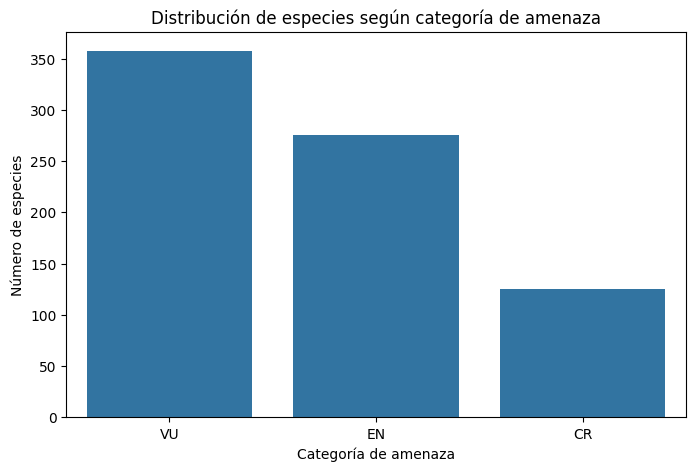

In [ ]:
orden = ['VU', 'EN', 'CR']

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='ESTADO DE AMENAZA',
    order=orden
)

plt.title('Distribución de especies según categoría de amenaza')
plt.xlabel('Categoría de amenaza')
plt.ylabel('Número de especies')

plt.show()

A través de la gráfica de barras, evidenciamos que hay 350 especies de animales dentro de la categoría (VU) Vulnerable, seguida de alrededor de 275 especies en categoría En Peligro (EN), y 125 en Peligro Crítico (CR).

## 5. Definimos los niveles taxonómicos

Se definen los niveles taxonómicos que se analizarán (Clase, Familia, Género y Especie) y luego muestra los nombres de las columnas disponibles en la base de datos. Esto permite verificar que las columnas necesarias existan y coincidan con los nombres utilizados en el análisis antes de continuar.

In [ ]:
niveles_taxonomicos = [
    'Clase',
    'Familia',
    'Genero',
    'Especie'
]

# Revisar los nombres reales de las columnas
print("Columnas disponibles en la base:")
print(df.columns.tolist())

Columnas disponibles en la base:
['IDENTIFICACION', 'IDENTIFICACION TAXONOMICA', 'NOMBRE CIENTIFICO', 'CLASIFICACION SUPERIOR', 'REINO', 'FILO', 'CLASE', 'ORDEN', 'FAMILIA', 'GENERO', 'EPITETO ESPECIFICO', 'EPITETO INFRAESPECIFICO', 'RANGO DE TAXON', 'NOMBRE CIENTIFICO 1', 'NOMBRE VERNACULO', 'CODIGO NOMENCLATURA', 'ESTADO TAXONOMICO', 'TAXON OBSERVACIONES', 'LENGUAJE', 'ESTADO DE AMENAZA']


## 6. Resumen de los niveles taxonómicos

Se genera una tabla resumen de los principales niveles taxonómicos (Clase, Familia, Género y Especie), indicando para cada uno el número de registros, valores únicos y datos faltantes. Permite evaluar la calidad y completitud de la información taxonómica de la base de datos y detectar posibles vacíos que puedan afectar el análisis de biodiversidad.

In [ ]:
resumen_taxonomico = []

# Mapeo de los niveles conceptuales a los nombres de columna reales en el DataFrame
column_name_mapping = {
    'Clase': 'CLASE',
    'Familia': 'FAMILIA',
    'Genero': 'GENERO',
    'Especie': 'NOMBRE CIENTIFICO' # Asumiendo que 'Especie' se refiere a esta columna
}

for nivel_conceptual in niveles_taxonomicos:
    # Obtener el nombre real de la columna usando el mapeo, si existe
    actual_column_name = column_name_mapping.get(nivel_conceptual, nivel_conceptual)

    if actual_column_name in df.columns:
        resumen_taxonomico.append({
            'Nivel_taxonomico': nivel_conceptual,
            'Registros': df.shape[0],
            'Valores_unicos': df[actual_column_name].nunique(),
            'Valores_faltantes': df[actual_column_name].isnull().sum()
        })
    else:
        # En caso de que el mapeo no encuentre una columna existente,
        # se puede registrar una advertencia o asignar valores por defecto.
        print(f"Advertencia: La columna '{actual_column_name}' (originalmente '{nivel_conceptual}') no se encontró en el DataFrame. Se asignarán valores por defecto.")
        resumen_taxonomico.append({
            'Nivel_taxonomico': nivel_conceptual,
            'Registros': df.shape[0],
            'Valores_unicos': 0, # O asignar np.nan
            'Valores_faltantes': df.shape[0] # Todos los registros como faltantes
        })

resumen_taxonomico = pd.DataFrame(resumen_taxonomico)

display(resumen_taxonomico)

,Nivel_taxonomico,Registros,Valores_unicos,Valores_faltantes
0,Clase,759,14,0
1,Familia,759,197,0
2,Genero,759,349,0
3,Especie,759,759,0


## 7. Mostrar especies amenazadas por nivel taxonómico

Se filtran las especies clasificadas como VU, EN y CR y se generan tablas que muestran cuántas especies amenazadas pertenecen a cada clase, familia, género y especie. Esto permite identificar qué grupos taxonómicos concentran una mayor cantidad de especies amenazadas, información útil para priorizar acciones de conservación y toma de decisiones.

In [ ]:
categorias_amenaza = ['VU', 'EN', 'CR']

df_amenazadas = df[
    df['ESTADO DE AMENAZA'].isin(categorias_amenaza)
].copy()

# Mapeo de los niveles conceptuales a los nombres de columna reales en el DataFrame
column_name_mapping = {
    'Clase': 'CLASE',
    'Familia': 'FAMILIA',
    'Genero': 'GENERO',
    'Especie': 'NOMBRE CIENTIFICO' # Asumiendo que 'Especie' se refiere a esta columna
}

for nivel_conceptual in niveles_taxonomicos:
    # Obtener el nombre real de la columna usando el mapeo
    actual_column_name = column_name_mapping.get(nivel_conceptual, nivel_conceptual)

    if actual_column_name in df_amenazadas.columns:
        print(f"\nEspecies amenazadas por {nivel_conceptual}:")

        tabla = (
            df_amenazadas[actual_column_name]
            .value_counts()
            .reset_index()
        )

        # Usar el nombre conceptual para la visualización
        tabla.columns = [nivel_conceptual, 'Especies_amenazadas']

        display(tabla)
    else:
        print(f"Advertencia: La columna '{actual_column_name}' (originalmente '{nivel_conceptual}') no se encontró en el DataFrame `df_amenazadas`.")


Especies amenazadas por Clase:


,Clase,Especies_amenazadas
0,Amphibia,290
1,Aves,139
2,Actinopterygii,93
3,Mammalia,71
4,Reptilia,44
5,Malacostraca,38
6,Insecta,34
7,Elasmobranchii,20
8,Anthozoa,9
9,Arachnida,8



Especies amenazadas por Familia:


,Familia,Especies_amenazadas
0,Strabomantidae,128
1,Bufonidae,47
2,Dendrobatidae,41
3,Centrolenidae,29
4,Pseudothelphusidae,23
...,...,...
192,Caviidae,1
193,Myrmecophagidae,1
194,Tayassuidae,1
195,Molossidae,1



Especies amenazadas por Genero:


,Genero,Especies_amenazadas
0,Pristimantis,110
1,Atelopus,33
2,Hyloscirtus,14
3,Nymphargus,12
4,Gastrotheca,10
...,...,...
344,Copaxa,1
345,Syssphinx,1
346,Anadara,1
347,Larkinia,1



Especies amenazadas por Especie:


,Especie,Especies_amenazadas
0,Odocoileus virginianus tropicalis,1
1,Anomalocardia flexuosa,1
2,Pristimantis xeniolum,1
3,Acropora cervicornis,1
4,Acropora palmata,1
...,...,...
754,Megaphobema robustum,1
755,Muricea crassa,1
756,Muricea austera,1
757,Pacifigorgia irene,1


Se observa que, en el nivel taxonómico de **Clase**, Amphibia presenta el mayor número de especies amenazadas, con **290 especies**, seguido de Actinopterygii con **93**, Mammalia con **71** y Reptilia con **44**.

En el nivel de **Familia**, las familias con mayor número de especies amenazadas son **Strabomantidae**, con 128 especies, seguida de **Bufonidae** con 47, **Dendrobatidae** con 41 y **Pseudothelphusidae** con 23. En cuanto al nivel de **Género**, se destaca ***Pristimantis***, con 110 especies amenazadas, seguido de **Atelopus** con 33, **Hyloscirtus** con 14, **Nymphargus** con 12 y **Gastrotheca** con 10.

Estos resultados muestran que **Amphibia lidera el número de especies amenazadas en el nivel de Clase y que esta tendencia se mantiene en los niveles taxonómicos inferiores**, particularmente en Familia y Género, donde se destacan Strabomantidae y Pristimantis, respectivamente. Esto evidencia una importante concentración de especies amenazadas de anfibios dentro del conjunto de datos analizado.

Entre las especies amenazadas de importancia identificadas se encuentran **Odocoileus virginianus tropicalis, Anomalocardia flexuosa, Acropora cervicornis, Acropora palmata** y, entre los anfibios, **Pristimantis xeniolum**.


## 8. KPI: Especies amenazadas por clase taxonómica

Este código aplica la función del KPI al nivel de Clase, calculando el número de especies amenazadas únicas dentro de cada clase taxonómica y ordenándolas de mayor a menor. Permite identificar qué clases concentran más especies amenazadas y orientar la priorización de acciones de conservación.

In [ ]:
def calcular_kpi_amenaza(df_data, columna_taxonomica):
    kpi = (
        df_data.groupby(columna_taxonomica)['NOMBRE CIENTIFICO']
        .nunique()
        .to_frame(name='Especies_amenazadas')
    )
    return kpi

kpi_clase = calcular_kpi_amenaza(
    df,
    'CLASE'
)

display(kpi_clase)

,Especies_amenazadas
CLASE,
Actinopterygii,93
Amphibia,290
Anthozoa,9
Arachnida,8
Aves,139
Bivalvia,6
Elasmobranchii,20
Gastropoda,4
Holothuroidea,2


Nuevamente señalamos que, el grupo taxonómico de Clase Amphibia es el que lidera la mayor cantidad de especies amenazadas dentro de nuestra base de datos con 290 especies.

## 9. Distribución de la severidad de la amenaza

Se calcula el número de especies únicas de cada clase taxonómica según su categoría de amenaza (CR, EN y VU). La tabla permite comparar la severidad y distribución de las especies amenazadas entre clases, facilitando la identificación de los grupos que requieren mayor atención.



In [ ]:
# Número de especies por categoría de amenaza
severidad = (
    df
    .groupby(['CLASE', 'ESTADO DE AMENAZA'])['NOMBRE CIENTIFICO']
    .nunique()
    .unstack(fill_value=0)
)

# Asegurar que existan las tres categorías
for categoria in ['CR', 'EN', 'VU']:
    if categoria not in severidad.columns:
        severidad[categoria] = 0

severidad = severidad[['CR', 'EN', 'VU']]

display(severidad)

ESTADO DE AMENAZA,CR,EN,VU
CLASE,,,
Actinopterygii,6,9,78
Amphibia,74,123,93
Anthozoa,1,2,6
Arachnida,0,3,5
Aves,16,56,67
Bivalvia,1,1,4
Elasmobranchii,2,1,17
Gastropoda,0,1,3
Holothuroidea,1,0,1


La Clase Amphibia cuenta con 74 especies en estado VU (Vulnerable), 123 en EN (En Peligro), y 93 en CR (Peligro Crítico) de extinción.

## 10. Puntaje de severidad

Se asigna un peso según la gravedad de la categoría de amenaza: CR = 3, EN = 2 y VU = 1. Luego calcula un puntaje para cada clase, dando mayor peso a las especies en categorías de mayor riesgo. Esto permite priorizar las clases taxonómicas con mayor nivel de amenaza, siendo más útil para la toma de decisiones que un simple conteo de especies.


**El rango depende del número de especies amenazadas que tenga cada clase:**

**Mínimo:** 0 → si una clase no tiene especies amenazadas.

**Máximo:** no tiene un límite fijo; depende de cuántas especies amenazadas haya en esa clase.


**Por ejemplo, si una clase tiene:**

2 CR → 2 × 3 = 6

3 EN → 3 × 2 = 6

5 VU → 5 × 1 = 5

Puntaje total = 17

In [ ]:
# Peso de cada categoría
pesos_amenaza = {
    'CR': 3,   # En peligro crítico
    'EN': 2,   # En peligro
    'VU': 1    # Vulnerable
}

# Calcular puntaje ponderado
severidad['Puntaje_severidad'] = (
    severidad['CR'] * pesos_amenaza['CR'] +
    severidad['EN'] * pesos_amenaza['EN'] +
    severidad['VU'] * pesos_amenaza['VU']
)

display(severidad)


ESTADO DE AMENAZA,CR,EN,VU,Puntaje_severidad
CLASE,,,,
Actinopterygii,6,9,78,114
Amphibia,74,123,93,561
Anthozoa,1,2,6,13
Arachnida,0,3,5,11
Aves,16,56,67,227
Bivalvia,1,1,4,9
Elasmobranchii,2,1,17,25
Gastropoda,0,1,3,5
Holothuroidea,1,0,1,4


Se normaliza el número de especies amenazadas y severidad de la amenaza para cada clase respecto a la clase con mayor cantidad.


El resultado genera un puntaje entre 0 y 1:

**1:** representa la clase con mayor número de especies amenazadas.

**Valores cercanos a 0:** representan una menor cantidad.

Se evidencia que Amphibia posee un puntaje de severidad de 561 de gravedad como categoría de amenaza de extinción, seguido de Aves con 227, y Actinopterygii con 114.

Posteriormente, se integra en una sola tabla la información sobre el número de especies amenazadas y su puntaje de severidad (CR, EN y VU) para cada clase taxonómica

In [ ]:
kpi_clase = (
    df.groupby('CLASE')['NOMBRE CIENTIFICO']
    .nunique()
    .to_frame(name='Especies_amenazadas')
)

severidad = (
    df.groupby(['CLASE', 'ESTADO DE AMENAZA'])['NOMBRE CIENTIFICO']
    .nunique()
    .unstack(fill_value=0)
)

# Asegurar que existan las categorías
for categoria in ['CR', 'EN', 'VU']:
    if categoria not in severidad.columns:
        severidad[categoria] = 0

severidad = severidad[['CR', 'EN', 'VU']]

severidad['Puntaje_severidad'] = (
    severidad['CR'] * 3 +
    severidad['EN'] * 2 +
    severidad['VU'] * 1
)

kpi_clase_prioridad = kpi_clase.join(severidad)

kpi_clase_prioridad['Puntaje_cantidad'] = (
    kpi_clase_prioridad['Especies_amenazadas'] /
    kpi_clase_prioridad['Especies_amenazadas'].max()
)

kpi_clase_prioridad['Puntaje_severidad_normalizado'] = (
    kpi_clase_prioridad['Puntaje_severidad'] /
    kpi_clase_prioridad['Puntaje_severidad'].max()
)

# 8. Índice de prioridad
kpi_clase_prioridad['Indice_prioridad'] = (
    0.60 * kpi_clase_prioridad['Puntaje_cantidad'] +
    0.40 * kpi_clase_prioridad['Puntaje_severidad_normalizado']
)

kpi_clase_prioridad = kpi_clase_prioridad.sort_values(
    'Indice_prioridad',
    ascending=False
)

display(kpi_clase_prioridad)

,Especies_amenazadas,CR,EN,VU,Puntaje_severidad,Puntaje_cantidad,Puntaje_severidad_normalizado,Indice_prioridad
CLASE,,,,,,,,
Amphibia,290,74,123,93,561,1.000000,1.000000,1.000000
Aves,139,16,56,67,227,0.479310,0.404635,0.449440
Actinopterygii,93,6,9,78,114,0.320690,0.203209,0.273697
Mammalia,71,7,24,40,109,0.244828,0.194296,0.224615
Reptilia,44,11,16,17,82,0.151724,0.146168,0.149502
Malacostraca,38,1,26,11,66,0.131034,0.117647,0.125680
Insecta,34,5,13,16,57,0.117241,0.101604,0.110987
Elasmobranchii,20,2,1,17,25,0.068966,0.044563,0.059205
Anthozoa,9,1,2,6,13,0.031034,0.023173,0.027890


**Especies_amenazadas_ Amphibia** = 290

CR = 74

EN = 123

VU = 93


**Puntaje_severidad ** = 561

**Puntaje_cantidad** = 1.000

**Puntaje_severidad_normalizado** = 1.000

**Indice_prioridad** = 1.00

## 11. Índice de prioridad de conservación

Se combinan dos componentes para calcular un índice de prioridad de conservación:

**60 %: cantidad de especies amenazadas.**

**40 %: severidad de la amenaza.**

El resultado permite identificar las clases taxonómicas que deberían recibir mayor prioridad en acciones de conservación, considerando tanto cuántas especies amenazadas concentran como la gravedad de sus categorías de amenaza.

**Ojo:** para que este índice quede correctamente escalado entre 0 y 1, Puntaje_severidad también debe estar normalizado. Si actualmente puede tomar valores mayores a 1, el 60/40 no representa realmente 60 % y 40 %.

In [ ]:
kpi_clase_prioridad = kpi_clase.join(severidad)

kpi_clase_prioridad = kpi_clase_prioridad.rename(
    columns={
        'Total_especies_amenazadas': 'Especies_amenazadas'
    }
)

kpi_clase_prioridad['Puntaje_cantidad'] = (
    kpi_clase_prioridad['Especies_amenazadas'] /
    kpi_clase_prioridad['Especies_amenazadas'].max()
)

kpi_clase_prioridad['Puntaje_severidad_normalizado'] = (
    kpi_clase_prioridad['Puntaje_severidad'] /
    kpi_clase_prioridad['Puntaje_severidad'].max()
)

kpi_clase_prioridad['Indice_prioridad'] = (
    0.60 * kpi_clase_prioridad['Puntaje_cantidad'] +
    0.40 * kpi_clase_prioridad['Puntaje_severidad_normalizado']
)

kpi_clase_prioridad = kpi_clase_prioridad.sort_values(
    'Indice_prioridad',
    ascending=False
)

display(kpi_clase_prioridad)

,Especies_amenazadas,CR,EN,VU,Puntaje_severidad,Puntaje_cantidad,Puntaje_severidad_normalizado,Indice_prioridad
CLASE,,,,,,,,
Amphibia,290,74,123,93,561,1.000000,1.000000,1.000000
Aves,139,16,56,67,227,0.479310,0.404635,0.449440
Actinopterygii,93,6,9,78,114,0.320690,0.203209,0.273697
Mammalia,71,7,24,40,109,0.244828,0.194296,0.224615
Reptilia,44,11,16,17,82,0.151724,0.146168,0.149502
Malacostraca,38,1,26,11,66,0.131034,0.117647,0.125680
Insecta,34,5,13,16,57,0.117241,0.101604,0.110987
Elasmobranchii,20,2,1,17,25,0.068966,0.044563,0.059205
Anthozoa,9,1,2,6,13,0.031034,0.023173,0.027890


## 12. Ranking de prioridad

Se asigna un ranking a cada clase taxonómica según su Indice_prioridad, ubicando en el puesto 1 a la clase con mayor prioridad. Luego organiza los resultados de mayor a menor y muestra las variables principales: número de especies amenazadas, categorías CR/EN/VU, puntaje de severidad e índice de prioridad.


**Importante:** antes de interpretar este ranking, conviene corregir la normalización del Puntaje_severidad que mencionamos anteriormente. De lo contrario, el índice puede estar dando un peso mayor al 40 % previsto.

In [ ]:
kpi_clase_prioridad['Ranking'] = (
    kpi_clase_prioridad['Indice_prioridad']
    .rank(
        method='min',
        ascending=False
    )
    .astype(int)
)

ranking_final_clase = (
    kpi_clase_prioridad
    .sort_values(
        'Indice_prioridad',
        ascending=False
    )
    [
        [
            'Ranking',
            'Especies_amenazadas',
            'CR',
            'EN',
            'VU',
            'Puntaje_severidad',
            'Indice_prioridad'
        ]
    ]
    .copy()
)

display(ranking_final_clase)

,Ranking,Especies_amenazadas,CR,EN,VU,Puntaje_severidad,Indice_prioridad
CLASE,,,,,,,
Amphibia,1,290,74,123,93,561,1.000000
Aves,2,139,16,56,67,227,0.449440
Actinopterygii,3,93,6,9,78,114,0.273697
Mammalia,4,71,7,24,40,109,0.224615
Reptilia,5,44,11,16,17,82,0.149502
Malacostraca,6,38,1,26,11,66,0.125680
Insecta,7,34,5,13,16,57,0.110987
Elasmobranchii,8,20,2,1,17,25,0.059205
Anthozoa,9,9,1,2,6,13,0.027890


Amphibia tiene 290 especies amenazadas, con 74 CR, 123 EN y 93 VU, su puntaje de severidad es: 561

## 13. Gráfica: especies amenazadas por clase

Se genera un gráfico de barras horizontales que compara el número de especies de fauna silvestre amenazadas entre las diferentes clases taxonómicas. Las clases se organizan de menor a mayor cantidad, facilitando la identificación visual de aquellas que concentran un mayor número de especies amenazadas, en este caso de la clase **Amphibia (anfibios)**:

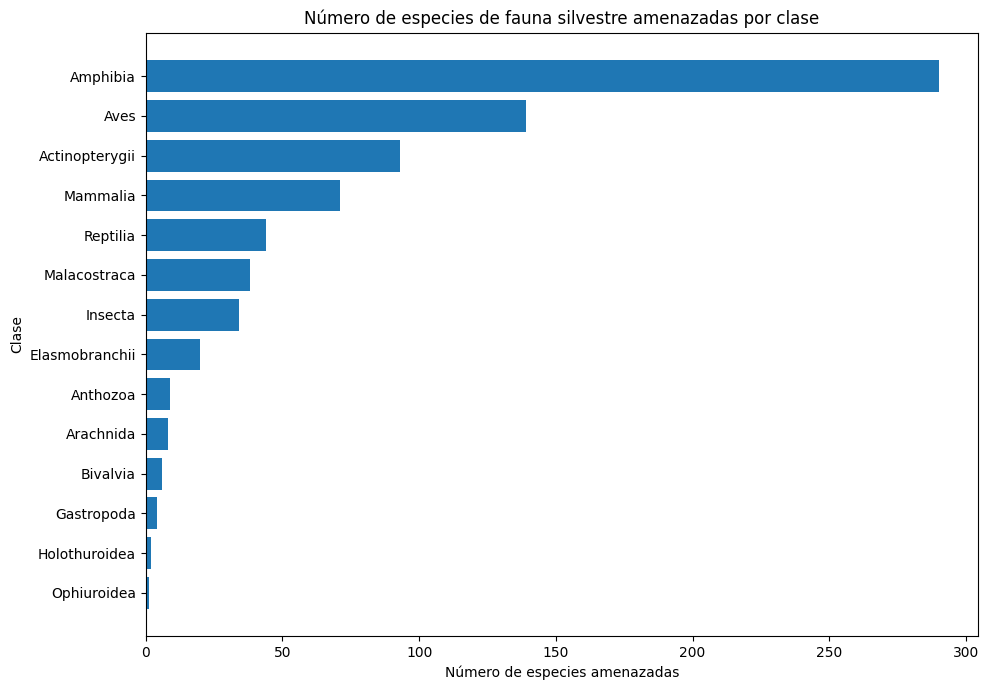

In [ ]:
grafica = (
    ranking_final_clase
    .sort_values(
        'Especies_amenazadas',
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    grafica.index.astype(str),
    grafica['Especies_amenazadas']
)

plt.xlabel('Número de especies amenazadas')
plt.ylabel('Clase')
plt.title(
    'Número de especies de fauna silvestre amenazadas por clase'
)

plt.tight_layout()
plt.show()

## 14. Gráfica: composición de la amenaza

Se genera un gráfico de barras horizontales apiladas que muestra, para cada clase taxonómica, cómo se distribuyen las especies amenazadas entre las categorías CR, EN y VU.

Permite visualizar no solo cuántas especies amenazadas tiene cada clase, sino también qué tan grave es su composición de amenaza, identificando las clases con mayor presencia de especies en categorías críticas (CR), en este caso a la nivel taxonómico de **Amphibia **que lidera con el mayor número de especies amenazadas:

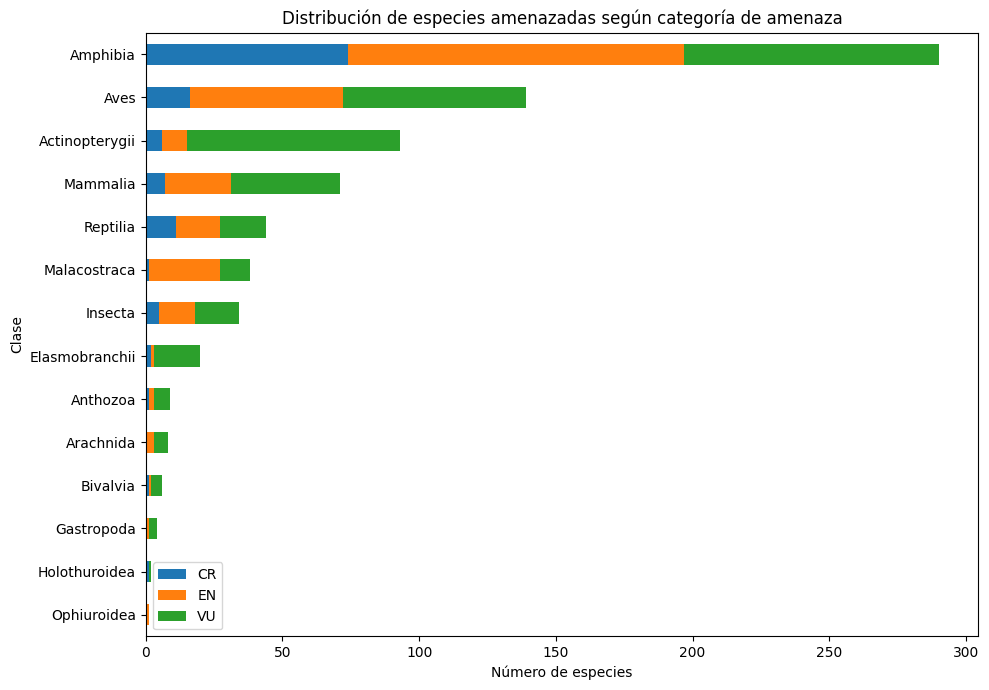

In [ ]:
severidad_grafica = (
    ranking_final_clase
    .sort_values(
        'Especies_amenazadas',
        ascending=True
    )
)

severidad_grafica[
    ['CR', 'EN', 'VU']
].plot(
    kind='barh',
    stacked=True,
    figsize=(10, 7)
)

plt.xlabel('Número de especies')
plt.ylabel('Clase')
plt.title(
    'Distribución de especies amenazadas según categoría de amenaza'
)

plt.tight_layout()
plt.show()

## Conclusiones

La clase **Amphibia** presenta la mayor prioridad de conservación dentro del análisis realizado, al concentrar **290 especies amenazadas: 74 en Peligro Crítico (CR), 123 En Peligro (EN) y 93 Vulnerables (VU)**. Además, obtuvo el **mayor puntaje de severidad (561)** y un **Índice de Prioridad de Conservación de 1,000**, siendo el valor más alto entre las clases analizadas.

Estos resultados evidencian que los anfibios representan un grupo que requiere especial atención dentro de las acciones gubernamentales de conservación. Su alta cantidad de especies amenazadas y la presencia de especies en categorías de **mayor riesgo resaltan la necesidad de fortalecer las estrategias de protección, recuperación y seguimiento de este grupo taxonómico.**

Por ello, la posición de Amphibia en el primer lugar del ranking permite orientar la priorización de recursos y acciones de conservación hacia la protección de sus especies y hábitats. No obstante, este índice constituye una **medida de prioridad relativa** y debe complementarse con información sobre distribución geográfica, tendencias poblacionales, presiones ambientales y medidas de manejo para establecer decisiones de conservación más integrales.